In [26]:
import pandas as pd

df = pd.read_csv("../data/diabetes.csv")
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [27]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [28]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace medically invalid zeros with NaN
df[zero_columns] = df[zero_columns].replace(0, np.nan)


X = df.drop("Outcome", axis=1)
y = df["Outcome"]


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)




# Calculate medians ONLY from training data
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)



# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

import joblib
import os

os.makedirs("../model", exist_ok=True)

joblib.dump(
    scaler,
    "../model/scaler.pkl"
)

print("Scaler saved successfully!")

print("\nShapes:")
print("Training:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)


# Convert targets to NumPy arrays
y_train = y_train.values
y_val = y_val.values
y_test = y_test.values


print("\nPreprocessing completed successfully!")

Scaler saved successfully!

Shapes:
Training: (537, 8)
Validation: (115, 8)
Test: (116, 8)

Preprocessing completed successfully!


In [29]:
import numpy as np
import time

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


print("Shapes:")
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# 2. CREATE LOGISTIC REGRESSION MODEL

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# 3. TRAIN MODEL

start_time = time.time()

model.fit(X_train, y_train)

training_time = time.time() - start_time

# 4. EVALUATE FUNCTION

def evaluate_model(X, y, dataset_name):

    # Predicted class
    y_pred = model.predict(X)

    # Probability of class 1
    y_prob = model.predict_proba(X)[:, 1]

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)

    print(f"\n----- {dataset_name} Results -----")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y, y_pred))

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }


# 5. VALIDATION RESULTS

val_results = evaluate_model(
    X_val,
    y_val,
    "Validation"
)


# 6. TEST RESULTS

test_results = evaluate_model(
    X_test,
    y_test,
    "Test"
)

# 7. PRINT TRAINING TIME

print("\nTraining Time:")
print(f"{training_time:.6f} seconds")

print("\nBaseline completed successfully!")

Shapes:
Training: (537, 8)
Validation: (115, 8)
Test: (116, 8)

----- Validation Results -----
Accuracy : 0.6957
Precision: 0.5641
Recall   : 0.5500
F1 Score : 0.5570
ROC-AUC  : 0.8037

Confusion Matrix:
[[58 17]
 [18 22]]

----- Test Results -----
Accuracy : 0.8017
Precision: 0.7812
Recall   : 0.6098
F1 Score : 0.6849
ROC-AUC  : 0.9076

Confusion Matrix:
[[68  7]
 [16 25]]

Training Time:
0.032709 seconds

Baseline completed successfully!


In [30]:
import matplotlib.pyplot as plt
import time
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def relu(z):
    return np.maximum(0, z)
def relu_derivative(z):
    return (z > 0).astype(float)

np.random.seed(42)

input_size = 8
hidden_size = 8
output_size = 1

# He initialization for ReLU layer
W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden_size))

# Xavier-style initialization for output layer
W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1 / hidden_size)
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

def forward_propagation(X):

    # Hidden layer
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    # Output layer
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    return Z1, A1, Z2, A2
Z1, A1, Z2, A2 = forward_propagation(X_train_scaled)

print("Output shape:", A2.shape)
print(A2[:5])

W1 shape: (8, 8)
b1 shape: (1, 8)
W2 shape: (8, 1)
b2 shape: (1, 1)
Output shape: (537, 1)
[[0.60168316]
 [0.57264714]
 [0.74796507]
 [0.80424708]
 [0.67104686]]


In [31]:
def binary_cross_entropy(y_true, y_pred):

    epsilon = 1e-8

    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )

    return loss
y_train_np = y_train.reshape(-1, 1)
y_val_np = y_val.reshape(-1, 1)
y_test_np = y_test.reshape(-1, 1)

In [32]:
def backward_propagation(X, y, Z1, A1, A2):

    m = X.shape[0]

    # Output layer gradients
    dZ2 = A2 - y

    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer gradients
    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

In [33]:
learning_rate = 0.01
epochs = 1000

train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(epochs):


    # FORWARD PROPAGATION

    Z1, A1, Z2, A2 = forward_propagation(X_train_scaled)

    train_loss = binary_cross_entropy(
        y_train_np,
        A2
    )

    # BACKPROPAGATION
    dW1, db1, dW2, db2 = backward_propagation(
        X_train_scaled,
        y_train_np,
        Z1,
        A1,
        A2
    )


    # UPDATE PARAMETERS

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2


    # VALIDATION

    _, _, _, val_predictions = forward_propagation(
        X_val_scaled
    )

    val_loss = binary_cross_entropy(
        y_val_np,
        val_predictions
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)


    # Print every 100 epochs
    if epoch % 100 == 0:

        print(
            f"Epoch {epoch} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {val_loss:.4f}"
        )


training_time_numpy = time.time() - start_time

print("\nTraining completed!")
print("Training time:", training_time_numpy)

Epoch 0 | Train Loss: 0.8997 | Validation Loss: 0.8658
Epoch 100 | Train Loss: 0.5868 | Validation Loss: 0.5951
Epoch 200 | Train Loss: 0.5246 | Validation Loss: 0.5480
Epoch 300 | Train Loss: 0.5010 | Validation Loss: 0.5313
Epoch 400 | Train Loss: 0.4866 | Validation Loss: 0.5219
Epoch 500 | Train Loss: 0.4758 | Validation Loss: 0.5152
Epoch 600 | Train Loss: 0.4671 | Validation Loss: 0.5101
Epoch 700 | Train Loss: 0.4591 | Validation Loss: 0.5057
Epoch 800 | Train Loss: 0.4521 | Validation Loss: 0.5024
Epoch 900 | Train Loss: 0.4458 | Validation Loss: 0.4997

Training completed!
Training time: 0.08857846260070801


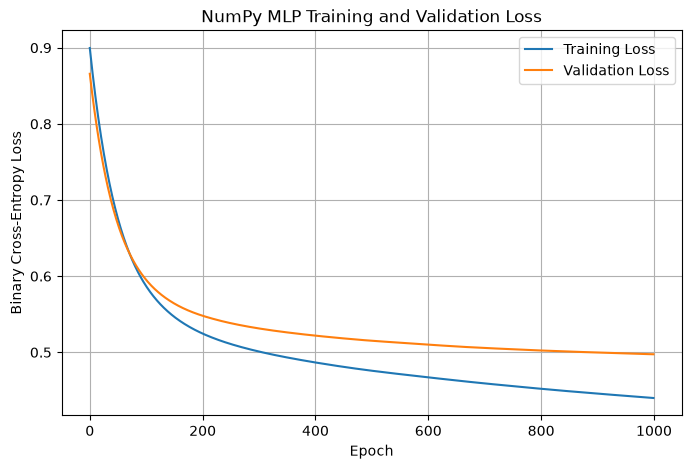

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("NumPy MLP Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [35]:
def predict_numpy(X):
    _, _, _, probabilities = forward_propagation(X)

    predictions = (probabilities >= 0.5).astype(int)

    return predictions, probabilities
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_numpy_mlp(X, y, dataset_name):

    y_pred, y_prob = predict_numpy(X)

    # Convert (n,1) arrays  (n,)
    y_pred = y_pred.flatten()
    y_prob = y_prob.flatten()

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, zero_division=0)
    recall = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    auc = roc_auc_score(y, y_prob)

    print(f"\n----- NumPy MLP {dataset_name} Results -----")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y, y_pred))

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }
val_results_numpy = evaluate_numpy_mlp(
    X_val_scaled,
    y_val,
    "Validation"
)


----- NumPy MLP Validation Results -----
Accuracy : 0.7130
Precision: 0.5814
Recall   : 0.6250
F1 Score : 0.6024
ROC-AUC  : 0.7877

Confusion Matrix:
[[57 18]
 [15 25]]


In [36]:
test_results_numpy = evaluate_numpy_mlp(
    X_test_scaled,
    y_test,
    "Test"
)


----- NumPy MLP Test Results -----
Accuracy : 0.7931
Precision: 0.7429
Recall   : 0.6341
F1 Score : 0.6842
ROC-AUC  : 0.8920

Confusion Matrix:
[[66  9]
 [15 26]]
